# Kalman Filter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import seaborn as sns

In [2]:
def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with DateTimeIndex.
    Each DataFrame is plotted as a separate line with the same style but different colors_line.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have DateTimeIndex)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have DateTimeIndex
    for i, df in enumerate(dfs):
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"DataFrame {i} must have a DateTimeIndex")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy().sort_index()

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot.loc[start_date:end_date]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label, color_line, color_scatter) in enumerate(zip(dfs_plot, labels, colors_line, colors_scatter)):
        if len(df_plot) == 0:
            continue

        # Plot types - all DataFrames use same style but different colors_line
        if plot_type == 'line':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            df_resampled = df_plot[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if not isinstance(filled_df.index, pd.DatetimeIndex):
            raise ValueError("filled_df must also have a DateTimeIndex")
        filled_copy = filled_df.copy().sort_index()

        # Find timestamps in filled_df but missing in original df
        new_times = filled_copy.index.difference(dfs[0].index)

        if not new_times.empty:
            filled_only = filled_copy.loc[new_times]
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only.loc[start_date:end_date]

            if not filled_only.empty:
                ax.scatter(filled_only.index, filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig

# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


In [3]:
graph2 = pd.read_csv('data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
def index_dataset(df, time_column):
    df[time_column] = pd.to_datetime(df[time_column])
    df.sort_values(time_column, inplace=True)
    df.set_index(time_column, inplace=True)
        
index_dataset(graph2, "Time of reading")
graph2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17267 entries, 2024-08-29 00:14:56 to 2025-08-29 17:06:45
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VAR_ID  17267 non-null  int64  
 1   Value   17267 non-null  float64
 2   Diff.   17266 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 539.6 KB


In [4]:
graph2["Diff."].isnull().values.sum()

1

In [5]:
graph2[graph2.isna().any(axis=1)]

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:14:56,55419,789.73,NaN


In [6]:
graph2 = graph2.dropna()
graph2.head()

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:44:56,55419,789.73,0.0
2024-08-29 01:14:56,55419,789.73,0.0
2024-08-29 01:44:56,55419,789.73,0.0
2024-08-29 02:14:56,55419,789.73,0.0
2024-08-29 02:44:56,55419,789.73,0.0


In [7]:
graph2_resampled = graph2.resample('30T').asfreq()
graph2_resampled["Diff."].isnull().values.sum()

C:\Users\Ondřej Černý\AppData\Local\Temp\ipykernel_2460\148022758.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  graph2_resampled = graph2.resample('30T').asfreq()


17554

In [8]:
class KalmanFilterRandomWalk:
    def __init__(self, Q=1e-5, R=1e-5, A=np.array([[1]])):
        # State transition matrix
        self.A = A
        # Observation matrix
        self.H = np.array([[1]])
        # Process noise covariance
        self.Q = np.array([[Q]])
        # Measurement noise covariance
        self.R = np.array([[R]])
        # Initial state estimate
        self.x_hat = None
        # Initial covariance estimate
        self.P = None
        
    def initialize(self, initial_state=0, initial_covariance=1):
        self.x_hat = np.array([[initial_state]])
        self.P = np.array([[initial_covariance]])
        
    def predict(self):
        # Predict the next state
        self.x_hat = self.A @ self.x_hat
        self.P = self.A @ self.P @ self.A.T + self.Q
        
    def update(self, measurement):
        # Innovation
        y_tilde = measurement - (self.H @ self.x_hat)
        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.R
        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)
        # Update state estimate
        self.x_hat = self.x_hat + K @ y_tilde
        # Update covariance estimate
        self.P = (np.eye(self.P.shape[0]) - K @ self.H) @ self.P
        return y_tilde, S  # Return innovation and its covariance

def run_kalman_filter_on_diff(df, Q=1e-5, R=1e-5, A=np.array([[1]])):
    """
    Runs Kalman filter on Diff. values of DataFrame df.
    Assumes df.index is the time of reading and df['Diff'] contains Diff. values.
    
    Returns:
    - df_results: original df with added columns for state estimate, innovation, and innovation magnitude
    """
    kf = KalmanFilterRandomWalk(Q=Q, R=R, A=A)
    kf.initialize(initial_state=0, initial_covariance=1)
    
    state_estimates = []
    innovation_vals = []
    innovation_magnitudes = []
    
    for diff_val in df['Diff.']:
        kf.predict()
        innovation, S = kf.update(np.array([[diff_val]]))
        state_estimates.append(kf.x_hat.item())
        innovation_vals.append(innovation.item())
        innovation_magnitudes.append(np.sqrt(innovation.T @ np.linalg.inv(S) @ innovation).item())
    
    df_results = df.copy()
    df_results['Diff.'] = state_estimates
    df_results['Innovation'] = innovation_vals
    df_results['Innovation_Magnitude'] = innovation_magnitudes
    
    return df_results

# Example usage:
# df is your DataFrame with DateTime index and 'Diff' column
graph2_last_week = graph2[-48*7:]
df_filtered = run_kalman_filter_on_diff(graph2_last_week, Q=0.00005, R=0.0009)
# You can then analyze df_filtered['Innovation_Magnitude'] for anomalies.


In [9]:
df_filtered.head()

,VAR_ID,Value,Diff.,Innovation,Innovation_Magnitude
Time of reading,,,,,
2025-08-22 17:36:55,55419,851.09,0.000000,0.000000,0.000000
2025-08-22 18:06:55,55419,851.09,0.000000,0.000000,0.000000
2025-08-22 18:36:55,55419,851.10,0.003626,0.010000,0.266126
2025-08-22 19:06:55,55419,851.10,0.002557,-0.003626,0.101493
2025-08-22 19:36:55,55419,851.10,0.001893,-0.002557,0.073340


DataFrame 1 (DF1): 336 points
DataFrame 2 (DF2): 336 points


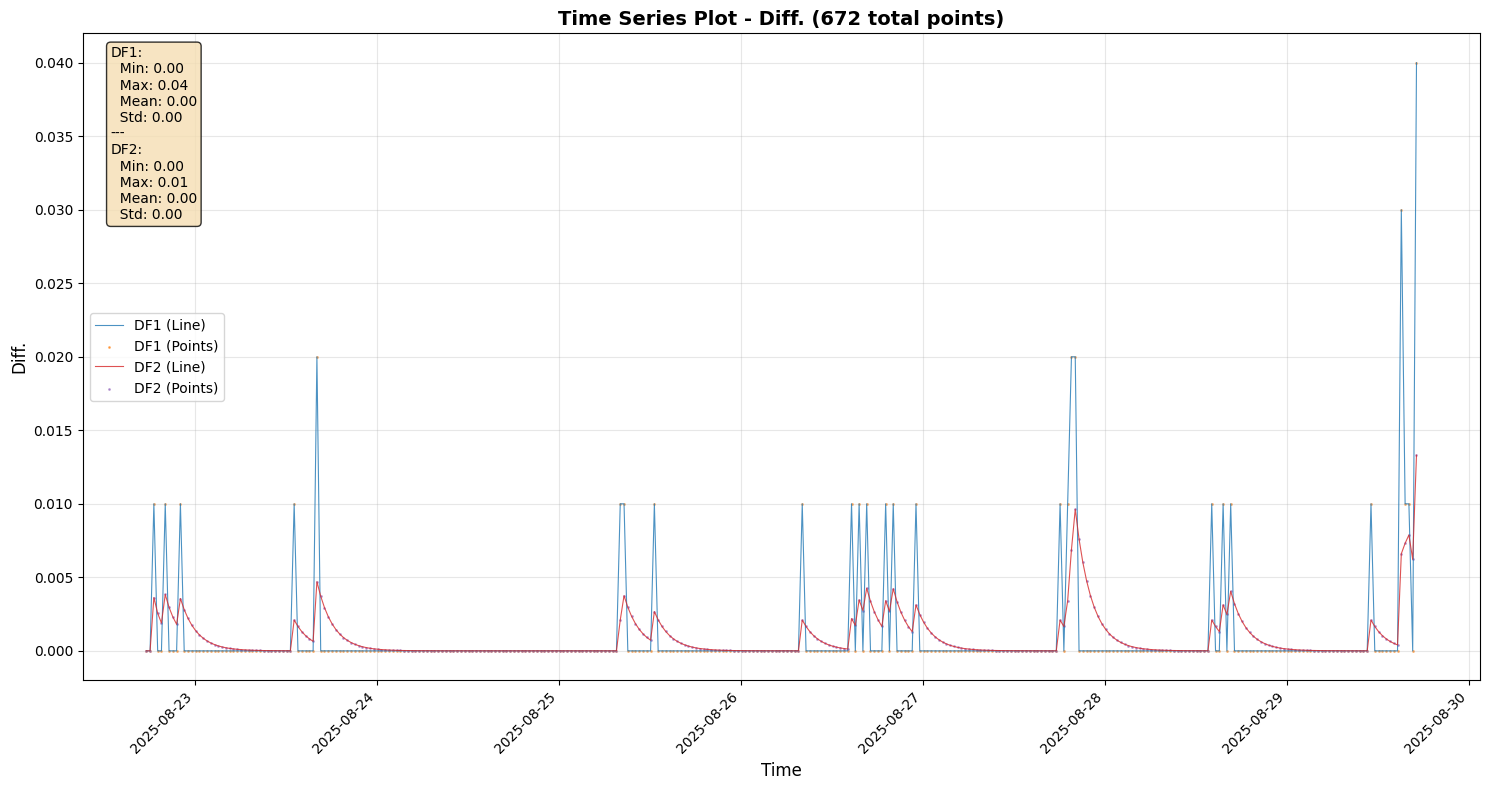

In [10]:
plot_timeseries([graph2_last_week, df_filtered], value_column="Diff.", plot_type="both")

## Seasonal KF

Structural models, statsmodels. Sarimax

In [11]:
def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with a 'timestamp' column.
    Each DataFrame is plotted as a separate line with the same style but different colors.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have 'timestamp' column)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have 'timestamp' column
    for i, df in enumerate(dfs):
        if 'timestamp' not in df.columns:
            raise ValueError(f"DataFrame {i} must have a 'timestamp' column")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))
        colors_scatter = colors_line  # Use same colors for scatter when many DFs

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy()
        
        # Ensure timestamp column is datetime
        df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot[(df_plot['timestamp'] >= start_date) & 
                             (df_plot['timestamp'] <= end_date)]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) == 0:
            continue

        # Get appropriate colors
        color_line = colors_line[i]
        color_scatter = colors_scatter[i] if i < len(colors_scatter) else color_line

        # Plot types - all DataFrames use same style but different colors
        if plot_type == 'line':
            ax.plot(df_plot['timestamp'], df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot['timestamp'], df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot['timestamp'], df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot['timestamp'], df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            # For resampling, temporarily set timestamp as index
            df_temp = df_plot.set_index('timestamp')
            df_resampled = df_temp[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if 'timestamp' not in filled_df.columns:
            raise ValueError("filled_df must also have a 'timestamp' column")
        
        filled_copy = filled_df.copy()
        filled_copy['timestamp'] = pd.to_datetime(filled_copy['timestamp'])
        filled_copy = filled_copy.sort_values('timestamp')

        # Find timestamps in filled_df but missing in original df
        original_timestamps = set(dfs[0]['timestamp'])
        filled_timestamps = set(filled_copy['timestamp'])
        new_times = filled_timestamps - original_timestamps

        if new_times:
            filled_only = filled_copy[filled_copy['timestamp'].isin(new_times)]
            
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only[(filled_only['timestamp'] >= start_date) & 
                                         (filled_only['timestamp'] <= end_date)]

            if not filled_only.empty:
                ax.scatter(filled_only['timestamp'], filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig


# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


In [12]:
graph2.head()

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:44:56,55419,789.73,0.0
2024-08-29 01:14:56,55419,789.73,0.0
2024-08-29 01:44:56,55419,789.73,0.0
2024-08-29 02:14:56,55419,789.73,0.0
2024-08-29 02:44:56,55419,789.73,0.0


In [13]:
filled_df = pd.read_csv("../filled_data_complete.csv")
filled_df.rename(columns={"Diff." : "Diff"}, inplace=True)
filled_df_last_week = filled_df.iloc[-48*7:]
filled_df_last_month = filled_df.iloc[-5*48*7:-48*7] # actually last 4 weeks before the last week

In [14]:
df2 = pd.read_csv('data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
df2.rename(columns={'VAR_ID':'id', 'Time of reading':'timestamp', 'Value':'hodnota', 'Diff.':'Diff'}, inplace=True)
# Convert 'timestamp' to datetime (if needed)
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')

# Sort by timestamp
df2 = df2.sort_values(by='timestamp')

# Reset index (optional, for a clean DataFrame)
df2 = df2.reset_index(drop=True)

display(df2.info())
display(df2.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17267 entries, 0 to 17266
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         17267 non-null  int64         
 1   timestamp  17267 non-null  datetime64[ns]
 2   hodnota    17267 non-null  float64       
 3   Diff       17266 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 539.7 KB


None

,id,timestamp,hodnota,Diff
0,55419,2024-08-29 00:14:56,789.73,NaN
1,55419,2024-08-29 00:44:56,789.73,0.0
2,55419,2024-08-29 01:14:56,789.73,0.0
3,55419,2024-08-29 01:44:56,789.73,0.0
4,55419,2024-08-29 02:14:56,789.73,0.0


In [15]:
test_df_last_4_weeks = df2.iloc[-4*7*48:]
test_df_8_to_4_weeks_ago = df2.iloc[(-8*7*48)+10:-4*7*48]
display(test_df_8_to_4_weeks_ago.tail())
display(test_df_last_4_weeks.head())
print(test_df_last_4_weeks.shape)
print(test_df_8_to_4_weeks_ago.shape)

,id,timestamp,hodnota,Diff
15918,55419,2025-08-01 15:07:25,849.67,0.00
15919,55419,2025-08-01 15:37:25,849.68,0.01
15920,55419,2025-08-01 16:07:25,849.68,0.00
15921,55419,2025-08-01 16:37:25,849.68,0.00
15922,55419,2025-08-01 17:07:25,849.68,0.00


,id,timestamp,hodnota,Diff
15923,55419,2025-08-01 17:37:25,849.68,0.0
15924,55419,2025-08-01 18:07:25,849.68,0.0
15925,55419,2025-08-01 18:37:25,849.68,0.0
15926,55419,2025-08-01 19:07:25,849.68,0.0
15927,55419,2025-08-01 19:37:25,849.68,0.0


(1344, 4)
(1334, 4)


DataFrame 1 (DF1): 17267 points


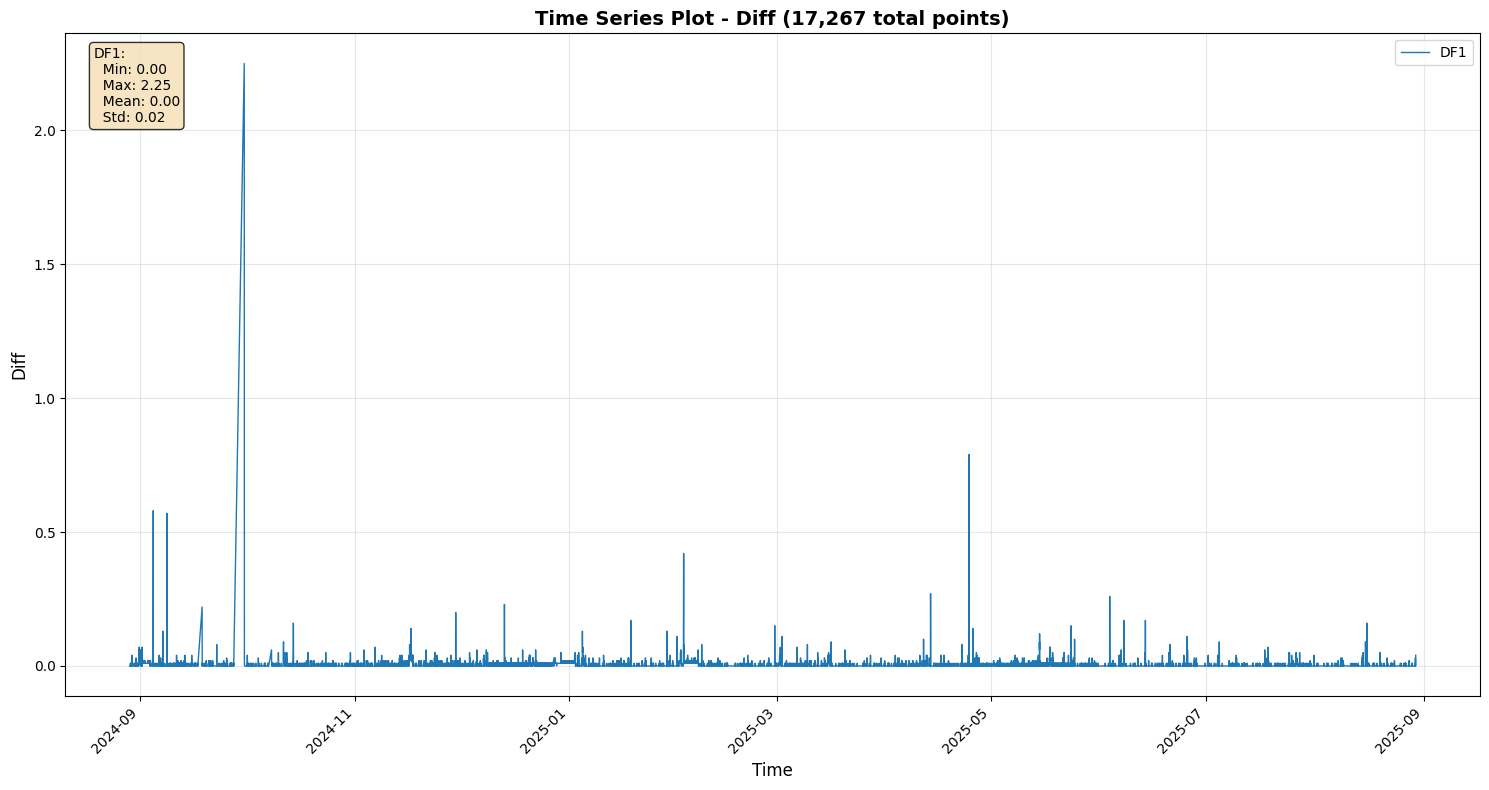

In [16]:
plot_timeseries([df2], 'Diff')

In [21]:
from kf_wrls_estimator import KalmanFilterWRLSEstimator

# First run (no previous data)")
estimator = KalmanFilterWRLSEstimator(lambda_forget=0.98)
A, Q, R, metadata = estimator.estimate_from_dataframe(
    df2,
    expected_interval_seconds=30*60,
    n_harmonics=1,
    tolerance_percent=10.0,
    verbose=True
)
estimator.save_matrices('sensor_test_df')


✓ Data Processing Summary:
  Time span: 8776.4 hours
  Expected readings (based on 1800s interval): 17553
  Expected pairs: 17552
  Valid pairs found: 17238
  Data validity: 98.2%


Starting WRLS estimation...
  State dimension: 3
  Forgetting factor λ = 0.98

  Processed 100/17238 updates... Max |eigval(A)| = 1.0000
  Processed 200/17238 updates... Max |eigval(A)| = 1.0000
  Processed 300/17238 updates... Max |eigval(A)| = 1.0000
  Processed 400/17238 updates... Max |eigval(A)| = 1.0000
  Processed 500/17238 updates... Max |eigval(A)| = 1.0000
  Processed 600/17238 updates... Max |eigval(A)| = 1.0000
  Processed 700/17238 updates... Max |eigval(A)| = 1.0000
  Processed 800/17238 updates... Max |eigval(A)| = 1.0000
  Processed 900/17238 updates... Max |eigval(A)| = 1.0000
  Processed 1000/17238 updates... Max |eigval(A)| = 1.0000
  Processed 1100/17238 updates... Max |eigval(A)| = 1.0000
  Processed 1200/17238 updates... Max |eigval(A)| = 1.0000
  Processed 1300/17238 updates... Max |e

In [22]:
eigvals = np.linalg.eigvals(A)
print("Final eigenvalues of A:", eigvals)
if np.any(np.abs(eigvals) > (1 + 1e-6)):
    print("WARNING: At least one eigenvalue of A is >= 1. Filtering may be unstable.")

Final eigenvalues of A: [0.16363335+0.j         0.99144514+0.13052415j 0.99144514-0.13052415j]


In [23]:
from kf import WaterMeterKalmanFilter

n_harmonics = 3
#R = np.eye(2*n_harmonics + 1) * 0.1
#Q = np.eye(2*n_harmonics + 1) * 0.0005
kf = WaterMeterKalmanFilter(A, Q, R, n_harmonics=3, seasonal_period=24.0)

df_filtered = kf.filter_dataframe(df2, return_diagnostics=True)


Kalman Filter Performance Metrics

Data Summary:
----------------------------------------------------------------------
  n_nonzero_measurements                       : 3533
  n_total_measurements                         : 17266
  nonzero_percentage                           : 20.462180
  n_anomalies_detected                         : 120

Prediction Accuracy (All Data):
----------------------------------------------------------------------
  MAE_prediction                               : 3.481400e-03
  RMSE_prediction                              : 0.022224
  ME_prediction                                : 3.095245e-03
  MedAE_prediction                             : 2.498485e-06
  MAPE_prediction                              : 1.725980e+08
  NRMSE_prediction                             : 0.997448
  R2_prediction                                : 5.096920e-03

Prediction Accuracy (Non-Zero Only):
----------------------------------------------------------------------
  MAE_prediction_no

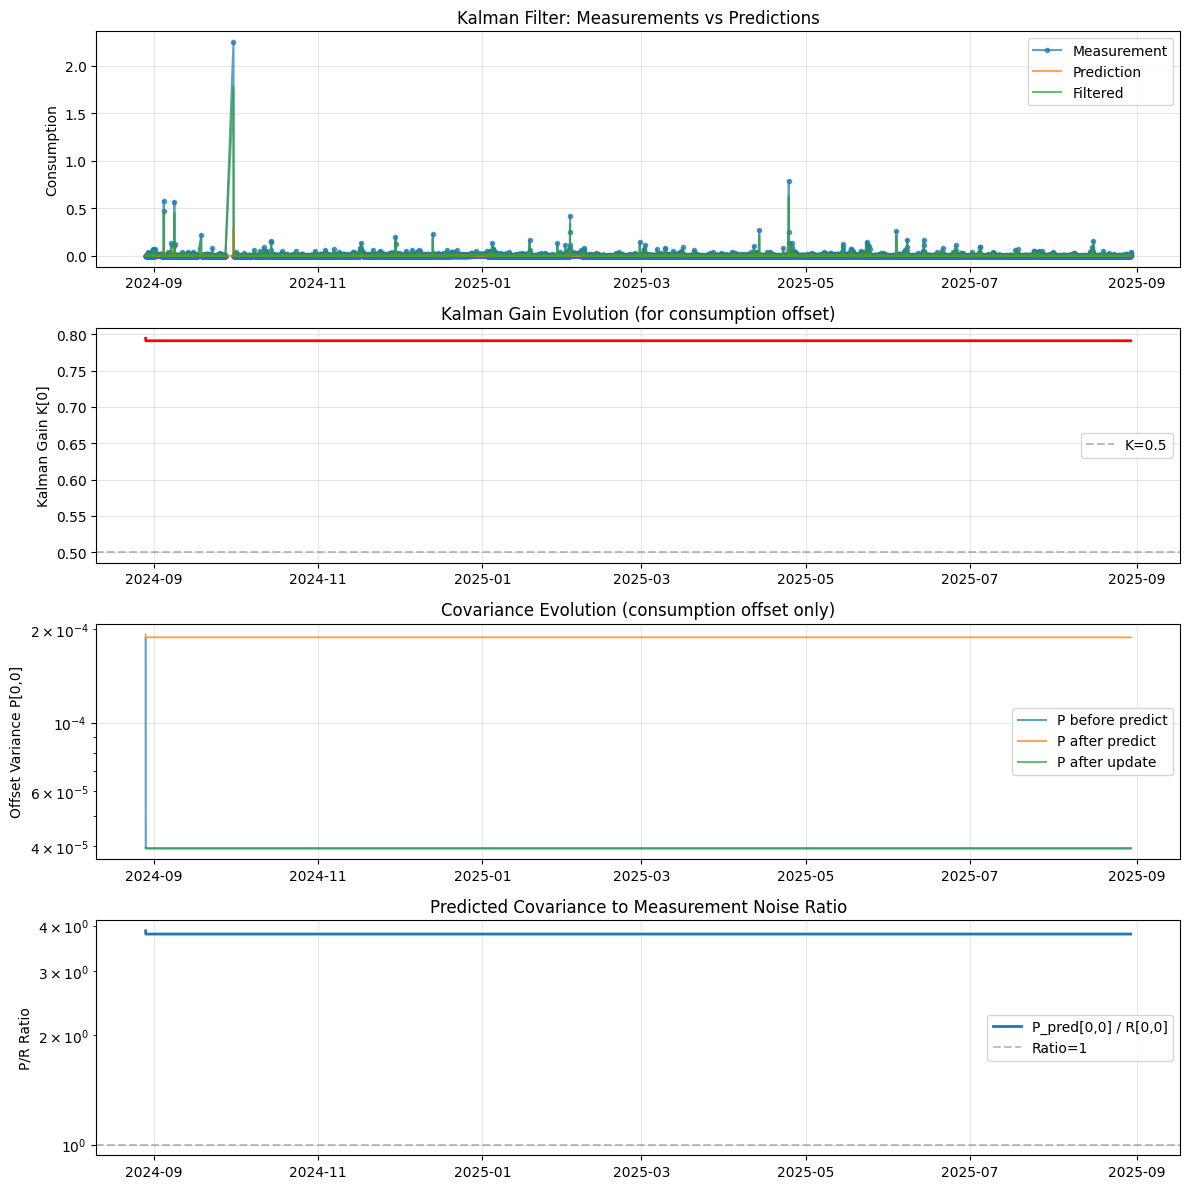


DIAGNOSTIC SUMMARY
K_offset - Mean: 0.7913, Min: 0.7913, Max: 0.7947
P_pred_offset_var - Mean: 1.882412e-04, Min: 1.882409e-04, Max: 1.922012e-04
P/R Ratio - Mean: 3.7917, Min: 3.7917, Max: 3.8715
Q/R Ratio (constant): 3.770535e+00


In [24]:
# Initialize filter
from kf_metrics import evaluate_kalman_filter, KalmanFilterMetrics

kf = WaterMeterKalmanFilter(A, Q, R, n_harmonics=3, seasonal_period=24.0)

df_filtered, metrics = evaluate_kalman_filter(kf, df2)

# Now you can plot the evolution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Plot 1: Measurements vs Predictions
axes[0].plot(df_filtered['timestamp'], df_filtered['Diff'], 
             label='Measurement', alpha=0.7, marker='.')
axes[0].plot(df_filtered['timestamp'], df_filtered['consumption_pred'], 
             label='Prediction', alpha=0.7)
axes[0].plot(df_filtered['timestamp'], df_filtered['consumption_filtered'], 
             label='Filtered', alpha=0.7)
axes[0].set_ylabel('Consumption')
axes[0].set_title('Kalman Filter: Measurements vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Kalman Gain for Offset
axes[1].plot(df_filtered['timestamp'], df_filtered['K_offset'], 
             color='red', linewidth=2)
axes[1].set_ylabel('Kalman Gain K[0]')
axes[1].set_title('Kalman Gain Evolution (for consumption offset)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='K=0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Covariance Evolution
axes[2].plot(df_filtered['timestamp'], df_filtered['P_before_offset_var'], 
             label='P before predict', alpha=0.7)
axes[2].plot(df_filtered['timestamp'], df_filtered['P_pred_offset_var'], 
             label='P after predict', alpha=0.7)
axes[2].plot(df_filtered['timestamp'], df_filtered['P_updated_offset_var'], 
             label='P after update', alpha=0.7)
axes[2].set_ylabel('Offset Variance P[0,0]')
axes[2].set_title('Covariance Evolution (consumption offset only)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Key Ratios
axes[3].plot(df_filtered['timestamp'], df_filtered['P_pred_to_R_ratio'], 
             label='P_pred[0,0] / R[0,0]', linewidth=2)
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio=1')
axes[3].set_ylabel('P/R Ratio')
axes[3].set_title('Predicted Covariance to Measurement Noise Ratio')
axes[3].set_yscale('log')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)
print(f"K_offset - Mean: {df_filtered['K_offset'].mean():.4f}, "
      f"Min: {df_filtered['K_offset'].min():.4f}, "
      f"Max: {df_filtered['K_offset'].max():.4f}")
print(f"P_pred_offset_var - Mean: {df_filtered['P_pred_offset_var'].mean():.6e}, "
      f"Min: {df_filtered['P_pred_offset_var'].min():.6e}, "
      f"Max: {df_filtered['P_pred_offset_var'].max():.6e}")
print(f"P/R Ratio - Mean: {df_filtered['P_pred_to_R_ratio'].mean():.4f}, "
      f"Min: {df_filtered['P_pred_to_R_ratio'].min():.4f}, "
      f"Max: {df_filtered['P_pred_to_R_ratio'].max():.4f}")
print(f"Q/R Ratio (constant): {df_filtered['Q_to_R_ratio'].iloc[0]:.6e}")
print("="*70)
